# Fine-tuning MACE foundation models

This tutorial focuses on **adapting a foundation interatomic potential to a new level of theory**. We use the carbonate-cluster XTB dataset from the previous tutorials as the target and compare two generations of MACE starting points:

- **MACE-MP-0 (small):** an early single-head universal materials model.
- **MACE-MH-1 (`omat_pbe` head):** the latest general-purpose cross-domain generation available through MACE 0.3.16.

We will:

1. review the generations of MACE foundation models;
2. understand why atomic reference energies, $E_0$, must be changed;
3. re-estimate $E_0$ values at the XTB target level;
4. fine-tune MP-0 and MH-1 on identical data and compare them;
5. introduce multihead replay and catastrophic forgetting;
6. condition MACE on total charge, spin, and other graph properties.

> **HPC companion:** every expensive section has a restartable stage in `T04_MACE_Finetuning.py`. The notebook deliberately does not launch training unless `RUN_TRAINING = True`.

## 1. Generations of MACE foundation models

Foundation models differ in **training domain**, **electronic-structure reference**, **architecture**, **heads**, and **license**. “Newer” does not automatically mean “best for every task.”

| Generation | Main data/reference | Scope and lesson | MACE alias |
|---|---|---|---|
| **MACE-MP-0** | MPTrj, PBE/PBE+U | First widely used universal MACE materials model; single reference head; MIT license | `small`, `medium`, `large` |
| **MP-0b / 0b2 / 0b3** | MPTrj variants | Improved radial forms, repulsion/stability, and reference treatment | `small-0b`, `medium-0b3`, ... |
| **MPA-0 / OMAT-0 / MATPES-0** | larger or alternative materials datasets | Better scale, pressure stability, or PBE/r2SCAN specialization | `medium-mpa-0`, `medium-omat-0`, ... |
| **MACE-OMOL-0** | OMOL, ωB97M-VV10 | Molecular/organometallic model with explicit total-charge and spin conditioning | `mace_omol()` |
| **MACE-MH-0 / MH-1** | OMAT + OMOL + OC20 + SPICE + RGD1 + MATPES | Cross-domain, multihead model spanning materials, molecules, surfaces, and reactions; ASL license | `mh-0`, `mh-1` |
| **MACE-POLAR-1** | OMOL, ωB97M-VV10 | Molecular/organometallic model with charge/spin conditioning and long-range electrostatics | `mace_polar()` |


### What is special about MH-1?

MH-1 shares a powerful representation across several electronic-structure references but retains separate readout heads. Important heads include:

- `omat_pbe` (default/general materials starting point),
- `omol` (ωB97M-VV10 molecular data),
- `spice_wB97M`,
- `rgd1_b3lyp`,
- `oc20_usemppbe`,
- `matpes_r2scan`.

For this controlled comparison we use **`omat_pbe`**, because it is the recommended general starting head and gives both MP-0 and MH-1 a PBE-family baseline before adapting to XTB.

Sources: [MACE foundation-model overview](https://github.com/ACEsuit/mace#pretrained-foundation-models), [MH-1 model card](https://huggingface.co/mace-foundations/mace-mh-1), and [fine-tuning guide](https://mace-docs.readthedocs.io/en/latest/guide/finetuning.html).

> MH-1 is the latest **general cross-domain** generation used here. MACE also has newer specialized families such as MACE-POLAR-1; those solve a different electrostatics problem and are outside this comparison.

In [ ]:
from pathlib import Path
import json
import os
import yaml

from ase.io import read

from hpc_common import choose_device
from T04_MACE_Finetuning import (
    FOUNDATIONS,
    TutorialPaths,
    analyze_e0_reestimation,
    compare_finetuned_models,
    make_finetune_config,
    make_replay_config,
    prepare_finetuning_data,
    run_omol_charge_example,
    train_replay_finetune,
    train_single_head_finetune,
    write_conditioning_examples,
)

# On MeluXina the shared data live here. Elsewhere, point MACE_TUTORIAL_DATA
# to a checkout containing data/solvent_xtb.xyz.
cluster_data = Path("/project/home/p201433/Tutorials")
local_data = Path.cwd() / "Tutorials"
default_data = cluster_data if cluster_data.exists() else local_data
WORK_DIR = Path(os.environ.get("MACE_TUTORIAL_DATA", default_data))
DEVICE = choose_device("auto")
paths = TutorialPaths.from_root(WORK_DIR.resolve())
paths.create_output_dirs()

print("Work directory:", paths.root)
print("Device:", DEVICE)

## 2. Prepare a target dataset without isolated atoms

The source file begins with isolated H, C, and O structures. Those are useful for understanding the **explicit XTB atomic energies**, but they must not be included in the fine-tuning file used below.

Why? MACE gives isolated atoms precedence when determining $E_0$. If they are present, `E0s: estimated` is bypassed. This tutorial intentionally creates a molecular-only training set so we can study and use the re-estimation procedure.

The split is:

- 50 molecular training configurations,
- 50 disjoint validation configurations,
- 1,000 held-out test configurations.


In [ ]:
prepare_finetuning_data(paths)

print("\nExplicit isolated-atom XTB values (for interpretation):")
print(paths.isolated_e0s.read_text())

## 3. Why changing $E_0$ is essential

MACE writes the total energy schematically as

$$
E(\mathbf R, \mathbf Z)
= \sum_i E_0(Z_i) + E_{\mathrm{interactions}}(\mathbf R, \mathbf Z).
$$

The first term is a large, composition-dependent baseline. The second contains the geometry-dependent chemistry the message-passing network learns.

A foundation model trained on PBE/PBE+U and a target dataset labeled by XTB do **not** share an energy zero. If we retain the foundation $E_0$ values, the optimizer first sees a huge systematic error that scales with the numbers of H, C, and O atoms. This can dominate bonding and conformational differences.

### Re-estimated $E_0$ values

MACE 0.3.16 supports `E0s: estimated` for foundation-model fine-tuning:

1. predict every target training structure with the selected foundation head;
2. compute $b = E_{\mathrm{XTB}} - E_{\mathrm{foundation}}$;
3. build a composition matrix $A$, where $A_{iZ}$ counts element $Z$ in configuration $i$;
4. solve the least-squares problem

$$
A\,\Delta E_0 \simeq b;
$$

5. set $E_0^{\mathrm{target}} = E_0^{\mathrm{foundation}} + \Delta E_0$.

This differs from `E0s: average`, which fits atomic baselines from the target dataset alone. Re-estimation corrects the **existing foundation decomposition** and is the preferred foundation-model option in current MACE.


In [ ]:
# Downloads/caches the small MP-0 and MH-1 checkpoints on first use.
# On the cluster, run this as the `e0s` Slurm stage rather than on a login node.
RUN_E0_ANALYSIS = False
if RUN_E0_ANALYSIS:
    analyze_e0_reestimation(paths, DEVICE)
else:
    print("Set RUN_E0_ANALYSIS=True, or submit STAGE=e0s, to run foundation predictions.")

### Interpreting the E0 diagnostic

The E0 stage reports, for each element:

- the selected foundation head's original $E_0$;
- the least-squares correction;
- the resulting XTB-level estimated $E_0$;
- the energy error per atom before and after removing the composition offset.

The error should decrease substantially, but it should **not become zero**: after the composition shift, differences in bonding, conformation, and intermolecular interactions remain. Those are what fine-tuning must learn.

The calculation is implemented transparently in `estimate_e0_corrections()` and the training jobs invoke the equivalent built-in path with `E0s: estimated`.


## 4. Single-head fine-tuning: MP-0 versus MH-1

The simplest protocol initializes from a foundation checkpoint and updates it only on the new XTB target data. MACE documentation calls this **naive** or **single-head fine-tuning**.

We hold fixed:

- target train/validation/test structures,
- XTB energy and force keys,
- E0 re-estimation,
- loss weights, batch size, optimizer settings, and epoch count.

Only the starting model changes. This is a comparison of practical starting points, **not a controlled architecture ablation**: MH-1 is larger and uses newer nonlinear blocks.


In [ ]:
mp0_config = make_finetune_config(paths, "mp0", DEVICE, epochs=30)
mh1_config = make_finetune_config(paths, "mh1", DEVICE, epochs=30)

print("MP-0 fine-tuning configuration:\n")
print(yaml.safe_dump(mp0_config, sort_keys=False))
print("MH-1 fine-tuning configuration:\n")
print(yaml.safe_dump(mh1_config, sort_keys=False))

In [ ]:
RUN_TRAINING = False  # Set True only inside an allocated GPU job.

if RUN_TRAINING:
    train_single_head_finetune(paths, "mp0", DEVICE, epochs=30)
    train_single_head_finetune(paths, "mh1", DEVICE, epochs=30)
else:
    print("Use the mp0 and mh1 Slurm stages shown at the end of the notebook.")

In [ ]:
RUN_COMPARISON = False

if RUN_COMPARISON:
    compare_finetuned_models(paths, DEVICE)
else:
    print("After training both models, set RUN_COMPARISON=True or submit STAGE=compare.")

## 5. Multihead replay fine-tuning

### The problem: catastrophic forgetting

Single-head fine-tuning shows the model only XTB carbonate clusters. Shared features can drift toward this narrow distribution and lose useful behavior learned from millions of diverse structures. A low target error does not guarantee that the model remains robust away from the target set.

### The replay idea

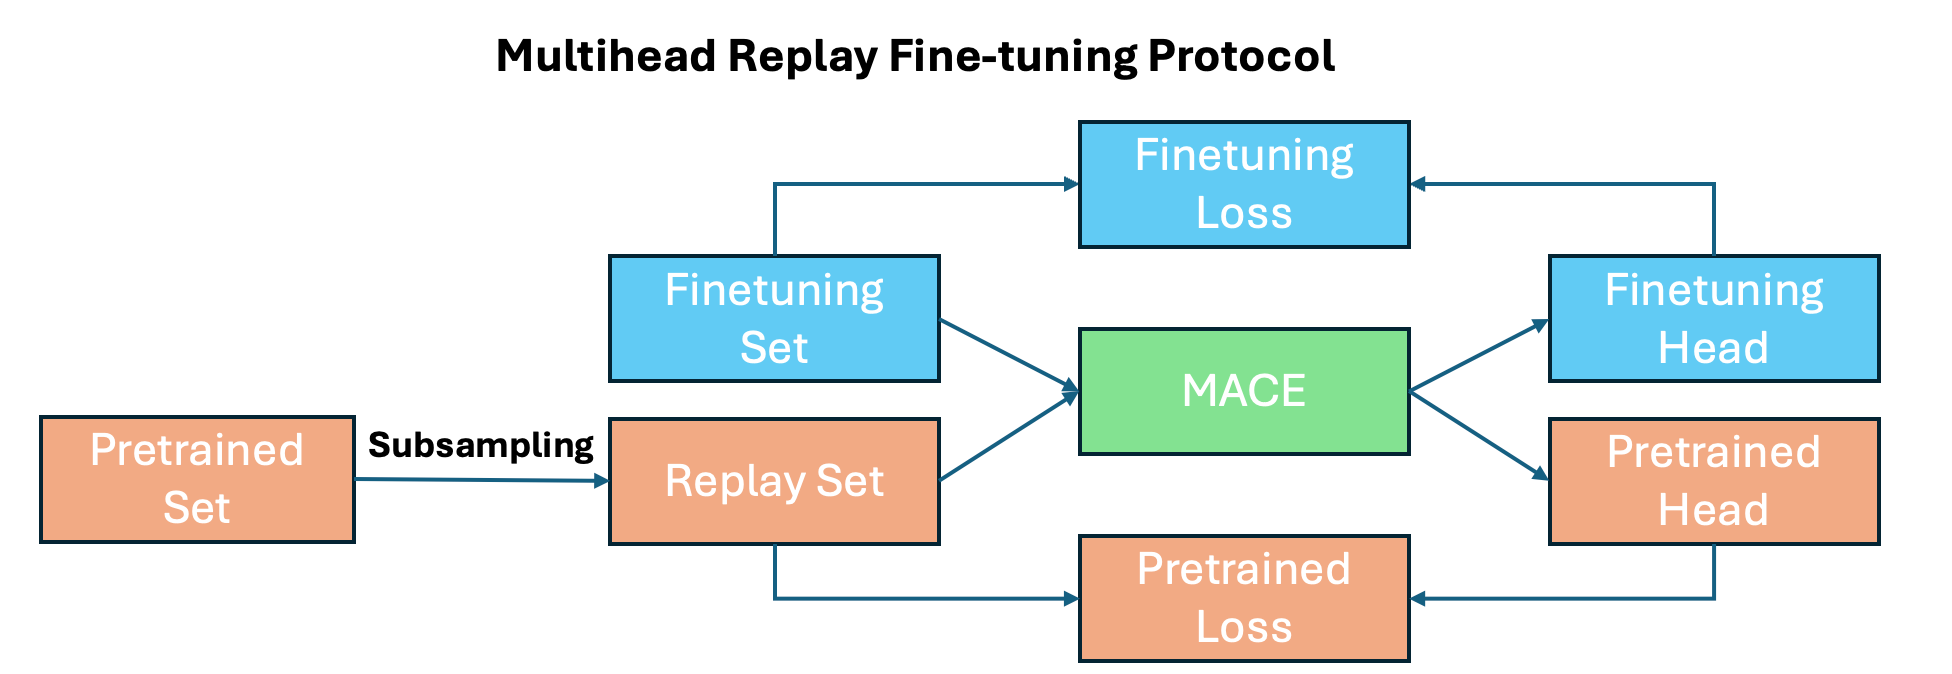
MACE creates two heads:

- **target (`Default`) head:** real XTB energies and forces;
- **pretraining (`pt_head`) head:** replay structures carrying the foundation model's original behavior.

Both heads share the representation network, but use separate readouts so inconsistent electronic-structure references do not need one common energy zero.

This tutorial uses **pseudolabel replay**:

1. download a small selection from the MP replay pool;
2. predict it using the starting `mh-1/omat_pbe` model;
3. store those predictions as replay labels;
4. train target and replay heads jointly.

Because pseudolabels reproduce the starting model, the initial replay error should be approximately zero. During fine-tuning, the replay loss resists destructive changes to shared features.

The lecture uses 100 random replay configurations for speed. Production studies commonly use many thousands and should investigate sampling, head weights, and target/replay ratios. See the [multihead replay guide](https://mace-docs.readthedocs.io/en/latest/guide/multihead_finetuning.html).


In [ ]:
replay_config = make_replay_config(
    paths,
    DEVICE,
    epochs=20,
    replay_samples=100,
)
print(yaml.safe_dump(replay_config, sort_keys=False))

In [ ]:
RUN_REPLAY = False

if RUN_REPLAY:
    train_replay_finetune(paths, DEVICE, epochs=20, replay_samples=100)
else:
    print("Set RUN_REPLAY=True in a GPU allocation, or submit STAGE=replay.")

### Comparing naive and replay fine-tuning

Run the comparison stage again after replay training. It automatically includes the replay model when present.

Compare at least three quantities:

1. XTB target test RMSE;
2. stability of high-temperature MD on the carbonate system;
3. retained performance on a broad validation set compatible with the original foundation head.

This tutorial automates the first. The second and third are important follow-up exercises: replay is intended to trade a small amount of target specialization for broader robustness.


## 6. Conditioning on total charge, spin, and other properties

Atomic numbers and positions do not uniquely specify the electronic state. MACE can embed extra inputs at either graph or atom level.

Common graph-level examples:

- `total_charge` (categorical),
- `total_spin` or spin multiplicity (categorical),
- electronic temperature (continuous),
- external fields or other scalar control variables.

A conditional model needs **labeled training configurations spanning those values**. Copying a neutral geometry, changing only its charge metadata, and retaining the neutral energy would create contradictory supervision. The helper below therefore writes:

- three **input-only** electronic-state examples;
- a YAML template showing `embedding_specs`;
- no fabricated charged-state labels.


In [ ]:
write_conditioning_examples(paths)

conditioning_inputs = read(paths.data / "conditioning_inputs.xyz", index=":")
for atoms in conditioning_inputs:
    print(atoms.info)

print("\nConditional training template:\n")
print((paths.configs / "conditional_mace_template.yml").read_text())

### Supplying properties at inference time

For a custom model trained with the template, use explicit `info_keys` so the calculator knows where ASE stores each model input:

```python
calc = MACECalculator(
    model_paths="conditional_mace.model",
    device="cuda",
    info_keys={
        "total_charge": "total_charge",
        "total_spin": "total_spin",
        "elec_temp": "elec_temp",
    },
)

atoms.info["total_charge"] = -1
atoms.info["total_spin"] = 2       # chosen convention must match training
atoms.info["elec_temp"] = 300.0
atoms.calc = calc
energy = atoms.get_potential_energy()
```

Property names and conventions are part of the model contract. In particular, document whether “spin” means multiplicity, $2S$, or another quantity.


## 7. A real charge/spin-aware foundation model: MACE-OMOL

MH-1 is multihead across datasets and electronic-structure methods, but that is conceptually different from conditioning every prediction on a supplied total charge. For an out-of-the-box charge/spin-aware molecular example, MACE 0.3.16 provides **MACE-OMOL**.

The optional example evaluates one geometry as:

- an anion doublet: charge $-1$, multiplicity 2;
- a neutral singlet: charge 0, multiplicity 1;
- a cation doublet: charge $+1$, multiplicity 2.

`mace_omol()` expects the convenient ASE keys `atoms.info["charge"]` and `atoms.info["spin"]`. It maps them internally to the model's total-charge and total-spin embeddings.

> The MACE-OMOL checkpoint is large and distributed under the Academic Software License. Run this only after reviewing and accepting the license.


In [ ]:
RUN_OMOL = False

if RUN_OMOL:
    run_omol_charge_example(paths, DEVICE)
else:
    print("Set RUN_OMOL=True in a GPU allocation, or submit STAGE=omol.")

## 8. Running the tutorial on MeluXina

From `/project/home/p201433/mace-tutorials`:

```bash
source /project/home/p201433/.venv-mace-tutorials/bin/activate

# Lightweight preparation
python T04_MACE_Finetuning.py \
  --work-dir /project/home/p201433/Tutorials \
  --stage prepare --device cpu

# Foundation predictions and E0 analysis
TUTORIAL=T04_MACE_Finetuning.py STAGE=e0s sbatch run_tutorial.slurm

# Fair single-head comparison
TUTORIAL=T04_MACE_Finetuning.py STAGE=mp0 sbatch run_tutorial.slurm
TUTORIAL=T04_MACE_Finetuning.py STAGE=mh1 sbatch run_tutorial.slurm
TUTORIAL=T04_MACE_Finetuning.py STAGE=compare sbatch run_tutorial.slurm

# Multihead pseudolabel replay
TUTORIAL=T04_MACE_Finetuning.py STAGE=replay sbatch run_tutorial.slurm
TUTORIAL=T04_MACE_Finetuning.py STAGE=compare sbatch run_tutorial.slurm

# Property-input template (no expensive training)
python T04_MACE_Finetuning.py \
  --work-dir /project/home/p201433/Tutorials \
  --stage properties --device cpu
```

For a one-epoch smoke run, add `TUTORIAL_EXTRA_ARGS="--epochs 1"` before `sbatch`. For a minimal replay smoke test, use `TUTORIAL_EXTRA_ARGS="--epochs 1 --replay-samples 3"`. Increase both values for a meaningful replay study and validate retained foundation-domain performance.

### Main conclusions

- Fine-tuning across electronic-structure methods begins with the energy reference, not the optimizer.
- `E0s: estimated` removes composition offsets while preserving the foundation decomposition.
- MP-0 and MH-1 provide different starting representations; compare them on identical splits.
- Replay protects broad behavior through a second head and shared-feature regularization.
- Charge/spin/property embeddings require correct metadata **and** reference labels that span those conditions.
